# Modeling WTI Crude Oil Prices with ARIMA and ARDL

This notebook implements the modeling stage of the project **“Modeling and Forecasting Monthly WTI Crude Oil Prices Using ARIMA and ARDL: The Role of the U.S. Dollar Index and the Federal Funds Rate, 2010–2025.”**

The workflow follows a clear time-series logic:

1. prepare the monthly modeling dataset;
2. split the data chronologically into training and test samples;
3. test stationarity to determine whether differencing is required;
4. estimate ARIMA models as univariate forecasting benchmarks;
5. estimate ARDL models to study the role of the U.S. Dollar Index and the Federal Funds Rate;
6. compare fixed multi-step forecasts and rolling one-step-ahead forecasts.

A key principle in this notebook is that **model selection and forecasting evaluation must respect the time order of the data**. Therefore, the test period is not used when estimating the models.

In [1]:
# 1. Import our tools (the libraries)
import pandas as pd
import yfinance as yf
import pandas_datareader as pdr
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

**Imported libraries.**  
The notebook uses `pandas` and `numpy` for data handling, `matplotlib` for visualization, `statsmodels` for ARIMA/ARDL/time-series diagnostics, and `arch` for the Phillips--Perron unit root test.

In [2]:
# Load the user's data
df_model = pd.read_csv('../data/oil_usd_interest_data_clean.csv', index_col=0, parse_dates=True)
# Make sure the index is datetime
df_model.index = pd.to_datetime(df_model.index)

# Sort by date
df_model = df_model.sort_index()

In [3]:
df_model["Log_WTI"] = np.log(df_model["WTI_Oil"])
df_model["Log_USD"] = np.log(df_model["USD_Index"])


### Data Preparation Note

The modeling dataset starts from the cleaned monthly data. Two log variables are created:

\[
Log\_WTI_t = \log(WTI\_Oil_t)
\]

\[
Log\_USD_t = \log(USD\_Index_t)
\]

WTI and USD Index are logged because they are positive price/index variables and log transformations make changes easier to interpret approximately in percentage terms. The interest rate is kept in level form because it contains values close to zero and is already measured as a percentage rate.

In [4]:
train = df_model.loc[: "2022-12-01"].copy()
test = df_model.loc["2023-01-01":].copy()

In [5]:
print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train period: 2010-01-01 00:00:00 to 2022-12-01 00:00:00
Test period: 2023-01-01 00:00:00 to 2025-12-01 00:00:00
Train shape: (156, 5)
Test shape: (36, 5)


### Train-Test Split Interpretation

The data are split chronologically:

- **Training sample:** January 2010 to December 2022, 156 observations.
- **Test sample:** January 2023 to December 2025, 36 observations.

This split is appropriate for time-series forecasting because it preserves the time order of the data and avoids look-ahead bias. Model identification, lag selection, and estimation are based on the training sample, while the test sample is reserved for out-of-sample evaluation.

In [6]:
train["D_Log_WTI"] = train["Log_WTI"].diff() * 100
train["D_Log_USD"] = train["Log_USD"].diff() * 100
train["D_Interest_Rate"] = train["Interest_Rate"].diff()
test["D_Log_WTI"] = test["Log_WTI"].diff() * 100
test["D_Log_USD"] = test["Log_USD"].diff() * 100
test["D_Interest_Rate"] = test["Interest_Rate"].diff()


### Differenced Variables

The first differences are created after the train-test split. This keeps the workflow clean and makes it clear that the training sample is used independently for model identification.

The transformed variables are:

- `D_Log_WTI`: monthly log change in WTI prices;
- `D_Log_USD`: monthly log change in the U.S. Dollar Index;
- `D_Interest_Rate`: monthly change in the Federal Funds Rate.

These variables are used mainly for stationarity testing and ARIMA identification.

## 2. Stationarity Tests on the Training Sample

Before estimating ARIMA and ARDL models, the time-series properties of the variables must be checked. This step is important because ARIMA requires the dependent series to be stationary after differencing, while ARDL bounds testing requires that none of the variables is integrated of order two, I(2).

The tests are applied to the **training sample only** so that model identification does not use information from the test period.

In [7]:
try:
    from arch.unitroot import PhillipsPerron
    pp_available = True
except ImportError:
    pp_available = False
    print("Package 'arch' is not installed. Install it using: pip install arch")

In [8]:
def stationarity_tests(series, series_name="Series"):
    """
    ADF null hypothesis: series has a unit root, non-stationary.
    KPSS null hypothesis: series is stationary.
    PP null hypothesis: series has a unit root, non-stationary.
    """
    
    x = series.dropna()
    
    print("=" * 70)
    print(f"Stationarity Tests for: {series_name}")
    print("=" * 70)
    print(f"Number of observations: {len(x)}")
    
    # ADF Test
    adf_result = adfuller(x, autolag="AIC")
    print("\nAugmented Dickey-Fuller Test")
    print(f"ADF Statistic : {adf_result[0]:.4f}")
    print(f"p-value       : {adf_result[1]:.4f}")
    print(f"Used lags     : {adf_result[2]}")
    print(f"Conclusion    : {'Stationary' if adf_result[1] < 0.05 else 'Non-stationary'} at 5% level")
    
    # KPSS Test
    try:
        kpss_result = kpss(x, regression="c", nlags="auto")
        print("\nKPSS Test")
        print(f"KPSS Statistic: {kpss_result[0]:.4f}")
        print(f"p-value       : {kpss_result[1]:.4f}")
        print(f"Used lags     : {kpss_result[2]}")
        print(f"Conclusion    : {'Non-stationary' if kpss_result[1] < 0.05 else 'Stationary'} at 5% level")
    except Exception as e:
        print("\nKPSS test failed:", e)
    
    # Phillips-Perron Test
    if pp_available:
        pp_result = PhillipsPerron(x)
        print("\nPhillips-Perron Test")
        print(f"PP Statistic  : {pp_result.stat:.4f}")
        print(f"p-value       : {pp_result.pvalue:.4f}")
        print(f"Conclusion    : {'Stationary' if pp_result.pvalue < 0.05 else 'Non-stationary'} at 5% level")

In [9]:
# Level / log-level variables
stationarity_tests(train["Log_WTI"], "Log WTI - Training Set")
stationarity_tests(train["Log_USD"], "Log USD Index - Training Set")
stationarity_tests(train["Interest_Rate"], "Interest Rate - Training Set")

# First differences
stationarity_tests(train["D_Log_WTI"], "First Difference of Log WTI - Training Set")
stationarity_tests(train["D_Log_USD"], "First Difference of Log USD Index - Training Set")
stationarity_tests(train["D_Interest_Rate"], "First Difference of Interest Rate - Training Set")

Stationarity Tests for: Log WTI - Training Set
Number of observations: 156

Augmented Dickey-Fuller Test
ADF Statistic : -2.0961
p-value       : 0.2461
Used lags     : 2
Conclusion    : Non-stationary at 5% level

KPSS Test
KPSS Statistic: 0.5587
p-value       : 0.0285
Used lags     : 8
Conclusion    : Non-stationary at 5% level

Phillips-Perron Test
PP Statistic  : -2.1301
p-value       : 0.2326
Conclusion    : Non-stationary at 5% level
Stationarity Tests for: Log USD Index - Training Set
Number of observations: 156

Augmented Dickey-Fuller Test
ADF Statistic : -1.0959
p-value       : 0.7167
Used lags     : 4
Conclusion    : Non-stationary at 5% level

KPSS Test
KPSS Statistic: 1.3868
p-value       : 0.0100
Used lags     : 8
Conclusion    : Non-stationary at 5% level

Phillips-Perron Test
PP Statistic  : -1.2843
p-value       : 0.6363
Conclusion    : Non-stationary at 5% level
Stationarity Tests for: Interest Rate - Training Set
Number of observations: 156

Augmented Dickey-Fuller Te

C:\Users\ACER\AppData\Local\Temp\ipykernel_8400\2371073864.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(x, regression="c", nlags="auto")
C:\Users\ACER\AppData\Local\Temp\ipykernel_8400\2371073864.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(x, regression="c", nlags="auto")
C:\Users\ACER\AppData\Local\Temp\ipykernel_8400\2371073864.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(x, regression="c", nlags="auto")
C:\Users\ACER\AppData\Local\Temp\ipykernel_8400\2371073864.py:25: InterpolationWarning: The test statistic is outside of the range of p-val

### Stationarity Test Interpretation

The unit root tests show that the level variables are generally non-stationary:

- `Log_WTI` is non-stationary in levels.
- `Log_USD` is non-stationary in levels.
- `Interest_Rate` is non-stationary in levels.

After first differencing, `D_Log_WTI` and `D_Log_USD` are clearly stationary. For `D_Interest_Rate`, ADF is less decisive, but KPSS and Phillips--Perron support stationarity. Overall, the variables are treated as **I(1)**.

This result has two implications:

1. For ARIMA, the differencing order should be set to \(d=1\).
2. For ARDL, the bounds testing framework is valid because no variable appears to be I(2).

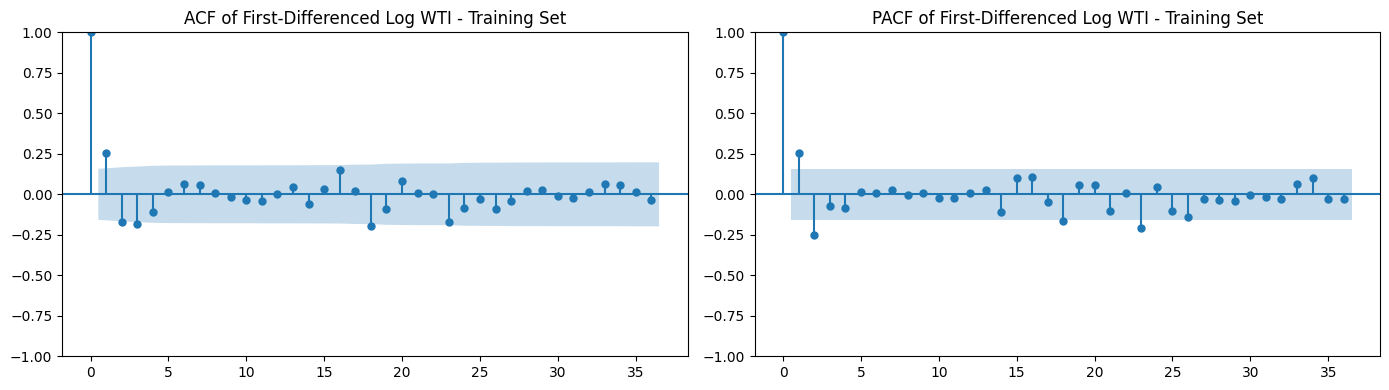

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(train["D_Log_WTI"].dropna(), lags=36, ax=axes[0])
axes[0].set_title("ACF of First-Differenced Log WTI - Training Set")

plot_pacf(train["D_Log_WTI"].dropna(), lags=36, ax=axes[1], method="ywm")
axes[1].set_title("PACF of First-Differenced Log WTI - Training Set")

plt.tight_layout()
plt.show()

### ACF/PACF Interpretation

The ACF and PACF of `D_Log_WTI` show that most of the persistence in log WTI is removed after first differencing. Only a few early lags appear relevant.

This supports estimating relatively low-order ARIMA models such as ARIMA(2,1,0), ARIMA(0,1,1), and ARIMA(2,1,1), rather than very large models.

## 3. ARIMA Modeling

The ARIMA model is used as a **univariate forecasting benchmark**. It uses only the past behavior of WTI prices and does not include the U.S. Dollar Index or the interest rate.

Because the unit root tests show that log WTI is non-stationary in levels but stationary after first differencing, the ARIMA specification fixes the differencing order at:

\[
d = 1.
\]

The next step searches across candidate \((p,q)\) combinations and compares them using AIC, BIC, and later out-of-sample forecast accuracy.

In [11]:
import warnings
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# Target variable
y_train = train["Log_WTI"].dropna()

# Candidate p and q
p_values = range(0, 6)
q_values = range(0, 6)

d = 1

arima_results = []

for p in p_values:
    for q in q_values:
        try:
            model = ARIMA(y_train, order=(p, d, q))
            fitted = model.fit()
            
            arima_results.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": fitted.aic,
                "BIC": fitted.bic,
                "HQIC": fitted.hqic
            })
            
        except Exception as e:
            continue

arima_results_df = pd.DataFrame(arima_results)
arima_results_df = arima_results_df.sort_values("AIC").reset_index(drop=True)

display(arima_results_df.head(10))

,p,d,q,AIC,BIC,HQIC
0,2,1,0,-249.827462,-240.697187,-246.118950
1,2,1,1,-249.202000,-237.028299,-244.257316
2,3,1,0,-248.692247,-236.518546,-243.747563
3,1,1,2,-248.010407,-235.836707,-243.065724
4,0,1,3,-247.834847,-235.661146,-242.890163
5,4,1,0,-247.648418,-232.431293,-241.467564
6,2,1,2,-247.249405,-232.032279,-241.068550
7,3,1,1,-247.225933,-232.008808,-241.045079
8,0,1,4,-247.208207,-231.991081,-241.027352
9,0,1,1,-247.163577,-241.076727,-244.691235


### ARIMA Candidate Selection

The ARIMA grid search fixes \(d=1\) and compares different \((p,q)\) combinations using AIC, BIC, and HQIC.

The lowest AIC is achieved by ARIMA(2,1,0), while ARIMA(2,1,1) is very close. The negative AIC and BIC values are not a problem. They occur because the model is estimated on log prices and the residual variance is small, which can produce a positive log-likelihood. AIC and BIC should be interpreted **comparatively**, not in absolute terms.

In [12]:
best_aic = arima_results_df.iloc[0]

best_order = (
    int(best_aic["p"]),
    int(best_aic["d"]),
    int(best_aic["q"])
)

print("Best ARIMA order by AIC:", best_order)
print(best_aic)

Best ARIMA order by AIC: (2, 1, 0)
p         2.000000
d         1.000000
q         0.000000
AIC    -249.827462
BIC    -240.697187
HQIC   -246.118950
Name: 0, dtype: float64


In [13]:
best_bic = arima_results_df.sort_values("BIC").iloc[0]

best_bic_order = (
    int(best_bic["p"]),
    int(best_bic["d"]),
    int(best_bic["q"])
)

print("Best ARIMA order by BIC:", best_bic_order)
print(best_bic)

Best ARIMA order by BIC: (0, 1, 1)
p         0.000000
d         1.000000
q         1.000000
AIC    -247.163577
BIC    -241.076727
HQIC   -244.691235
Name: 9, dtype: float64


### AIC versus BIC

AIC selects ARIMA(2,1,0), while BIC selects ARIMA(0,1,1). This difference is expected because BIC penalizes model complexity more strongly.

At this stage, the model should not be chosen only from AIC or BIC. Residual diagnostics and out-of-sample forecast performance are also needed.

In [14]:
final_arima_model = ARIMA(y_train, order=best_order)
final_arima_result = final_arima_model.fit()

print(final_arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Log_WTI   No. Observations:                  156
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 127.914
Date:                Mon, 01 Jun 2026   AIC                           -249.827
Time:                        00:09:30   BIC                           -240.697
Sample:                    01-01-2010   HQIC                          -246.119
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3170      0.062      5.112      0.000       0.195       0.439
ar.L2         -0.2486      0.088     -2.827      0.005      -0.421      -0.076
sigma2         0.0112      0.001     14.914      0.0

### Initial ARIMA Fit

The ARIMA(2,1,0) model is the AIC-best model in-sample. Its AR terms are statistically meaningful, and it provides a reasonable first candidate.

However, the first residuals of an ARIMA model with differencing can be affected by initialization. Therefore, residual diagnostics should be repeated after removing the initial burn-in observations.

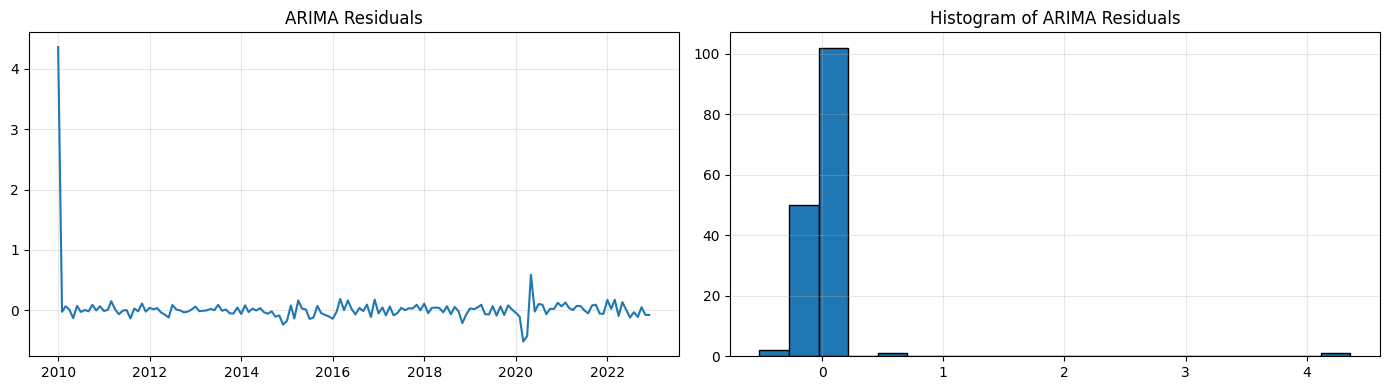

In [15]:
residuals = final_arima_result.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals)
axes[0].set_title("ARIMA Residuals")
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals.dropna(), bins=20, edgecolor="black")
axes[1].set_title("Histogram of ARIMA Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

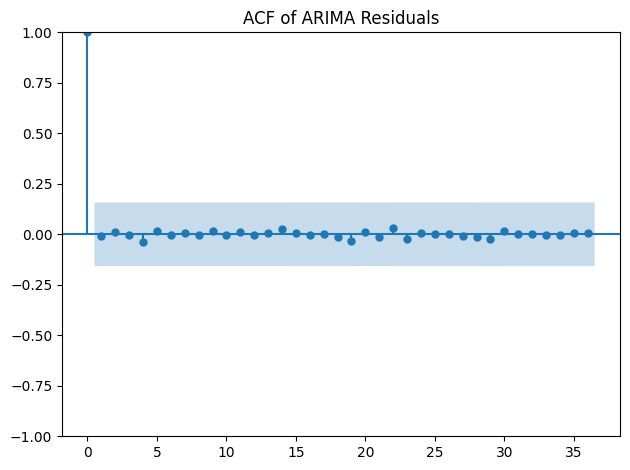

In [16]:
plot_acf(residuals.dropna(), lags=36)
plt.title("ACF of ARIMA Residuals")
plt.tight_layout()
plt.show()

In [17]:
# Clean residuals by removing initial observations affected by ARIMA initialization
residuals = final_arima_result.resid.copy()

burn = best_order[0] + best_order[1] + best_order[2]
burn = max(burn, 1)

residuals_clean = residuals.iloc[burn:]

print("Original residuals:", len(residuals))
print("Clean residuals:", len(residuals_clean))
print("Burn-in observations removed:", burn)

Original residuals: 156
Clean residuals: 153
Burn-in observations removed: 3


### Why Clean the ARIMA Residuals?

The first few ARIMA residuals may be distorted by model initialization, especially when differencing is used. Removing a small burn-in period gives a cleaner view of the residual behavior.

For ARIMA(2,1,0), the burn-in length is:

\[
p+d+q = 2+1+0 = 3.
\]

This cleaned residual series is more appropriate for diagnostic tests.

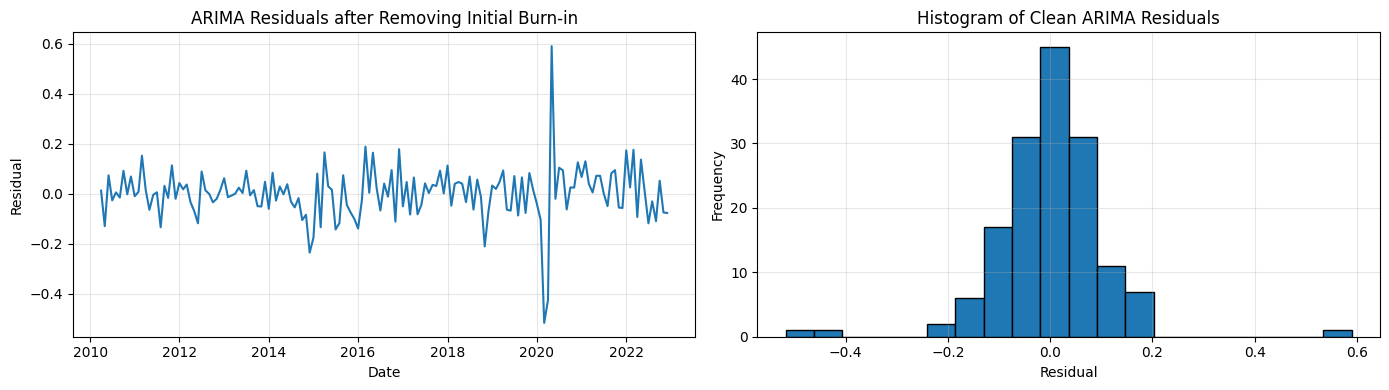

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals_clean)
axes[0].set_title("ARIMA Residuals after Removing Initial Burn-in")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_clean.dropna(), bins=20, edgecolor="black")
axes[1].set_title("Histogram of Clean ARIMA Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_clean = acorr_ljungbox(
    residuals_clean.dropna(),
    lags=[6, 12, 18, 24],
    return_df=True
)

display(ljung_box_clean)

,lb_stat,lb_pvalue
6,1.830351,0.934621
12,2.531716,0.998044
18,11.961859,0.849200
24,23.892475,0.467760


In [20]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(residuals_clean.dropna())

print("Jarque-Bera Test for Clean ARIMA Residuals")
print(f"JB Statistic: {jb_stat:.4f}")
print(f"p-value     : {jb_pvalue:.4f}")

Jarque-Bera Test for Clean ARIMA Residuals
JB Statistic: 561.4646
p-value     : 0.0000


### Clean ARIMA Residual Diagnostics

After removing the burn-in observations, the Ljung--Box p-values are all above 0.05. This indicates that the ARIMA residuals do not show significant remaining autocorrelation.

The Jarque--Bera test still rejects normality. This is not surprising for crude oil prices because oil price changes often have fat tails and extreme shocks, especially around crisis periods such as COVID-19.

The model is therefore acceptable as a forecasting benchmark, but forecast intervals should be interpreted with caution.

In [21]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Candidate ARIMA models
candidate_orders = [
    (2, 1, 0),  # Best by AIC
    (0, 1, 1),  # Best by BIC
    (2, 1, 1),  # Second best by AIC
    (3, 1, 0),  # Third best by AIC
    (0, 1, 0)   # Random walk benchmark
]

y_train = train["Log_WTI"].dropna()
y_test_price = test["WTI_Oil"]

forecast_results = []
forecast_store = {}

for order in candidate_orders:
    try:
        model = ARIMA(y_train, order=order)
        result = model.fit()
        
        forecast_obj = result.get_forecast(steps=len(test))
        forecast_log = forecast_obj.predicted_mean
        forecast_log.index = test.index
        
        forecast_price = np.exp(forecast_log)
        
        mae = mean_absolute_error(y_test_price, forecast_price)
        rmse = np.sqrt(mean_squared_error(y_test_price, forecast_price))
        mape = np.mean(np.abs((y_test_price - forecast_price) / y_test_price)) * 100
        
        forecast_results.append({
            "Model": f"ARIMA{order}",
            "Order": order,
            "AIC": result.aic,
            "BIC": result.bic,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })
        
        forecast_store[order] = {
            "result": result,
            "forecast_price": forecast_price,
            "forecast_obj": forecast_obj
        }
        
    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

forecast_results_df = pd.DataFrame(forecast_results)
forecast_results_df = forecast_results_df.sort_values("RMSE").reset_index(drop=True)

display(forecast_results_df)

,Model,Order,AIC,BIC,MAE,RMSE,MAPE
0,"ARIMA(0, 1, 1)","(0, 1, 1)",-247.163577,-241.076727,6.299589,7.630577,8.934756
1,"ARIMA(0, 1, 0)","(0, 1, 0)",-233.577925,-230.534500,6.587171,8.200689,9.566957
2,"ARIMA(2, 1, 0)","(2, 1, 0)",-249.827462,-240.697187,6.698395,8.297493,9.736713
3,"ARIMA(3, 1, 0)","(3, 1, 0)",-248.692247,-236.518546,6.841070,8.490049,9.977975
4,"ARIMA(2, 1, 1)","(2, 1, 1)",-249.202000,-237.028299,7.233189,9.008663,10.618368


### Fixed Multi-Step ARIMA Forecast Results

The fixed multi-step forecast evaluates what the model predicts for the full 2023–2025 test period using only information available up to December 2022.

The best fixed ARIMA forecast is ARIMA(0,1,1), with:

- MAE = 6.30
- RMSE = 7.63
- MAPE = 8.93%

The random walk benchmark ARIMA(0,1,0) is close behind. This shows that WTI prices are highly persistent and that simple benchmarks are difficult to outperform.

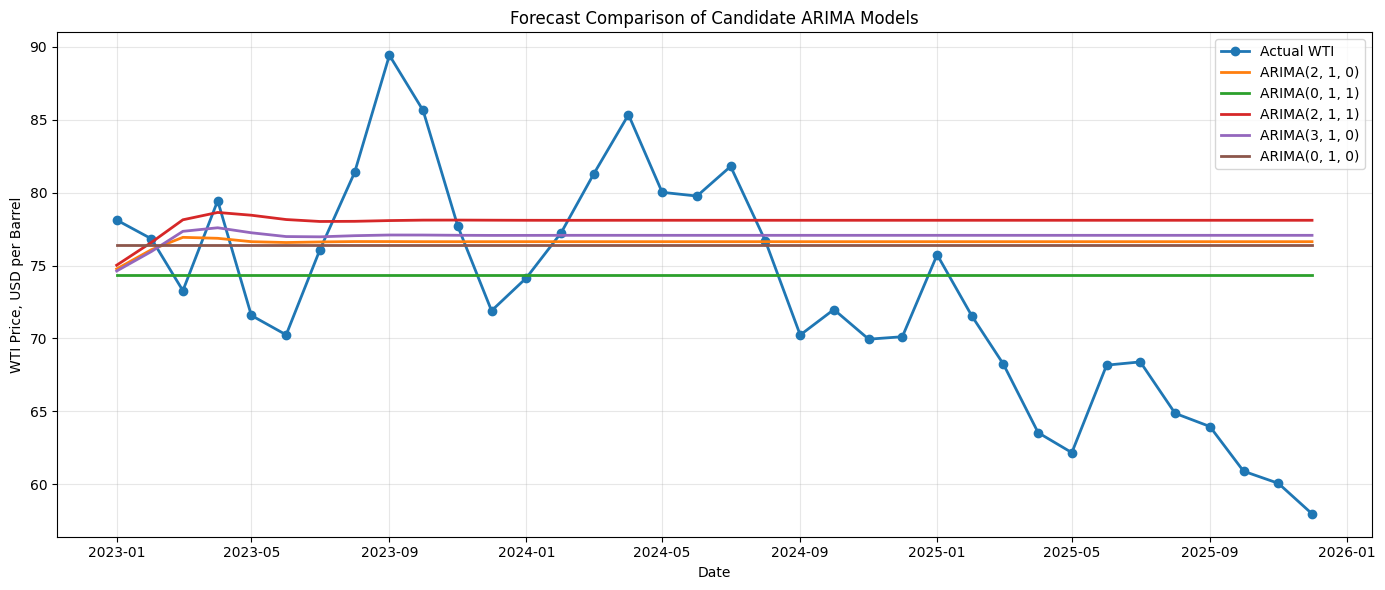

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test["WTI_Oil"],
    label="Actual WTI",
    linewidth=2,
    marker="o"
)

for order in candidate_orders:
    if order in forecast_store:
        plt.plot(
            test.index,
            forecast_store[order]["forecast_price"],
            label=f"ARIMA{order}",
            linewidth=2
        )

plt.title("Forecast Comparison of Candidate ARIMA Models")
plt.xlabel("Date")
plt.ylabel("WTI Price, USD per Barrel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Fixed Forecast Plot Interpretation

The fixed ARIMA forecasts are relatively flat. This is expected for ARIMA models with first differencing and no strong drift: future expected changes gradually converge toward zero, so the forecast stays close to the last observed training value.

This is not a coding error. It shows the limitation of long-horizon univariate ARIMA forecasting when no new information is incorporated.

In [23]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

candidate_orders = [
    (0, 1, 1),  # Best test performance so far
    (0, 1, 0),  # Random walk benchmark
    (2, 1, 0),  # AIC best
    (3, 1, 0),
    (2, 1, 1)
]

rolling_results = []
rolling_forecasts_store = {}

for order in candidate_orders:
    history = list(train["Log_WTI"].dropna())
    forecasts_log = []
    
    for t in range(len(test)):
        try:
            model = ARIMA(history, order=order)
            result = model.fit()
            
            forecast_log = result.forecast(steps=1)[0]
            forecasts_log.append(forecast_log)
            
            # Update history with actual observed Log_WTI from test
            actual_log = test["Log_WTI"].iloc[t]
            history.append(actual_log)
            
        except Exception as e:
            print(f"ARIMA{order} failed at step {t}: {e}")
            forecasts_log.append(np.nan)
            history.append(test["Log_WTI"].iloc[t])
    
    forecasts_price = np.exp(pd.Series(forecasts_log, index=test.index))
    rolling_forecasts_store[order] = forecasts_price
    
    actual_price = test["WTI_Oil"]
    
    mae = mean_absolute_error(actual_price, forecasts_price)
    rmse = np.sqrt(mean_squared_error(actual_price, forecasts_price))
    mape = np.mean(np.abs((actual_price - forecasts_price) / actual_price)) * 100
    
    rolling_results.append({
        "Model": f"ARIMA{order}",
        "Order": order,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

rolling_results_df = pd.DataFrame(rolling_results)
rolling_results_df = rolling_results_df.sort_values("RMSE").reset_index(drop=True)

display(rolling_results_df)

,Model,Order,MAE,RMSE,MAPE
0,"ARIMA(2, 1, 1)","(2, 1, 1)",3.567539,4.182851,4.819121
1,"ARIMA(3, 1, 0)","(3, 1, 0)",3.615508,4.242834,4.878887
2,"ARIMA(2, 1, 0)","(2, 1, 0)",3.614461,4.260691,4.869582
3,"ARIMA(0, 1, 0)","(0, 1, 0)",3.639380,4.280612,4.906252
4,"ARIMA(0, 1, 1)","(0, 1, 1)",3.679032,4.311336,4.944043


### Rolling One-Step ARIMA Forecast Results

The rolling one-step-ahead forecast updates the information set each month before forecasting the next month. This is not data leakage because the model only uses information available up to the previous month.

The best rolling model is ARIMA(2,1,1), with:

- MAE = 3.57
- RMSE = 4.18
- MAPE = 4.82%

However, the improvement over the random walk benchmark is small. This suggests that short-run WTI forecasts are strongly driven by price persistence.

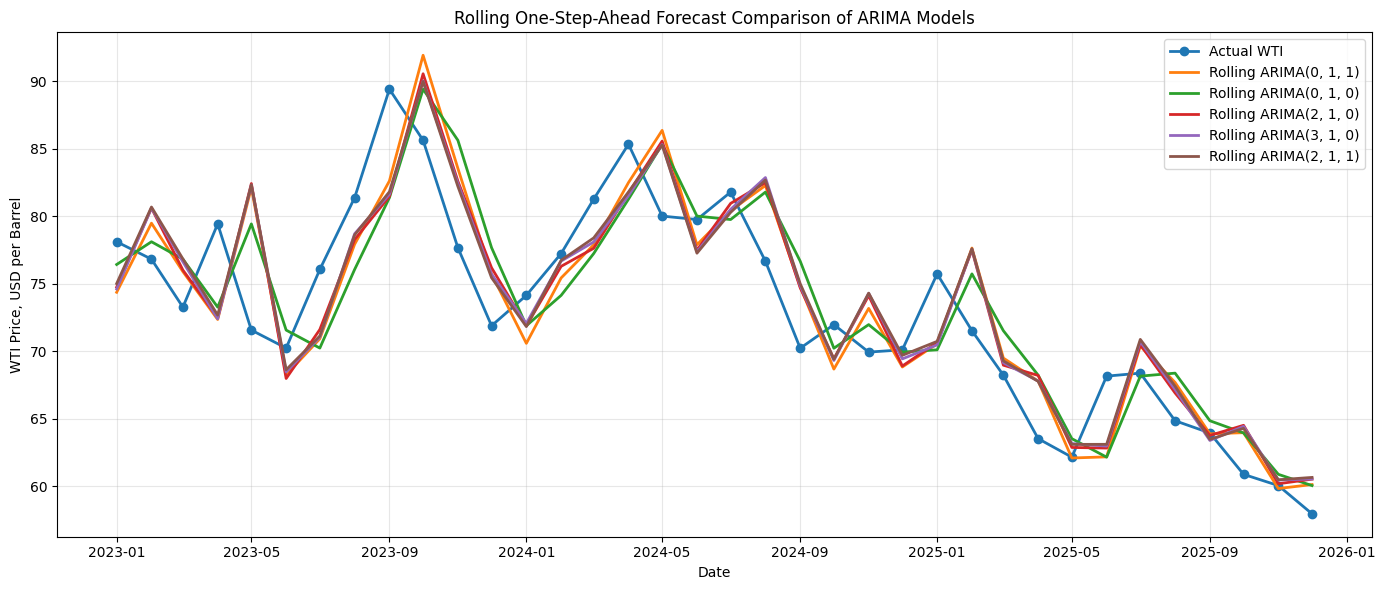

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test["WTI_Oil"],
    label="Actual WTI",
    linewidth=2,
    marker="o"
)

for order in candidate_orders:
    plt.plot(
        test.index,
        rolling_forecasts_store[order],
        label=f"Rolling ARIMA{order}",
        linewidth=2
    )

plt.title("Rolling One-Step-Ahead Forecast Comparison of ARIMA Models")
plt.xlabel("Date")
plt.ylabel("WTI Price, USD per Barrel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Rolling Forecast Plot Interpretation

The rolling ARIMA forecasts track actual WTI prices much more closely than the fixed multi-step forecasts because the model is updated as new monthly data become available.

This rolling result should be interpreted as the main short-run forecasting evaluation, while the fixed forecast is mainly useful for showing the limitation of long-horizon forecasts.

In [25]:
drift_results = []

for order in candidate_orders:
    try:
        model = ARIMA(y_train, order=order, trend="t")
        result = model.fit()
        
        forecast_obj = result.get_forecast(steps=len(test))
        forecast_log = forecast_obj.predicted_mean
        forecast_log.index = test.index
        
        forecast_price = np.exp(forecast_log)
        
        mae = mean_absolute_error(test["WTI_Oil"], forecast_price)
        rmse = np.sqrt(mean_squared_error(test["WTI_Oil"], forecast_price))
        mape = np.mean(np.abs((test["WTI_Oil"] - forecast_price) / test["WTI_Oil"])) * 100
        
        drift_results.append({
            "Model": f"ARIMA{order} with drift",
            "Order": order,
            "AIC": result.aic,
            "BIC": result.bic,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })
        
    except Exception as e:
        print(f"ARIMA{order} with drift failed: {e}")

drift_results_df = pd.DataFrame(drift_results)
drift_results_df = drift_results_df.sort_values("RMSE").reset_index(drop=True)

display(drift_results_df)

,Model,Order,AIC,BIC,MAE,RMSE,MAPE
0,"ARIMA(0, 1, 1) with drift","(0, 1, 1)",-245.164830,-236.034555,6.075035,7.342719,8.547340
1,"ARIMA(2, 1, 0) with drift","(2, 1, 0)",-247.828259,-235.654559,6.509925,8.016374,9.427832
2,"ARIMA(0, 1, 0) with drift","(0, 1, 0)",-231.578225,-225.491375,6.470922,8.029362,9.376531
3,"ARIMA(3, 1, 0) with drift","(3, 1, 0)",-246.693049,-231.475923,6.640443,8.209723,9.656171
4,"ARIMA(2, 1, 1) with drift","(2, 1, 1)",-247.202286,-231.985160,7.101269,8.830607,10.411646


### ARIMA with Drift

ARIMA models with drift are tested as a robustness check. The drift specification improves some fixed forecasts slightly, but it does not outperform the rolling one-step approach.

Therefore, drift is not selected as the main forecasting strategy. The final ARIMA comparison focuses on rolling one-step forecast accuracy.

In [26]:
final_order = (2, 1, 1)

final_arima_model = ARIMA(y_train, order=final_order)
final_arima_result = final_arima_model.fit()

print(final_arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Log_WTI   No. Observations:                  156
Model:                 ARIMA(2, 1, 1)   Log Likelihood                 128.601
Date:                Mon, 01 Jun 2026   AIC                           -249.202
Time:                        00:09:38   BIC                           -237.028
Sample:                    01-01-2010   HQIC                          -244.257
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6665      0.354      1.884      0.060      -0.027       1.360
ar.L2         -0.3351      0.112     -2.982      0.003      -0.555      -0.115
ma.L1         -0.3772      0.367     -1.028      0.3

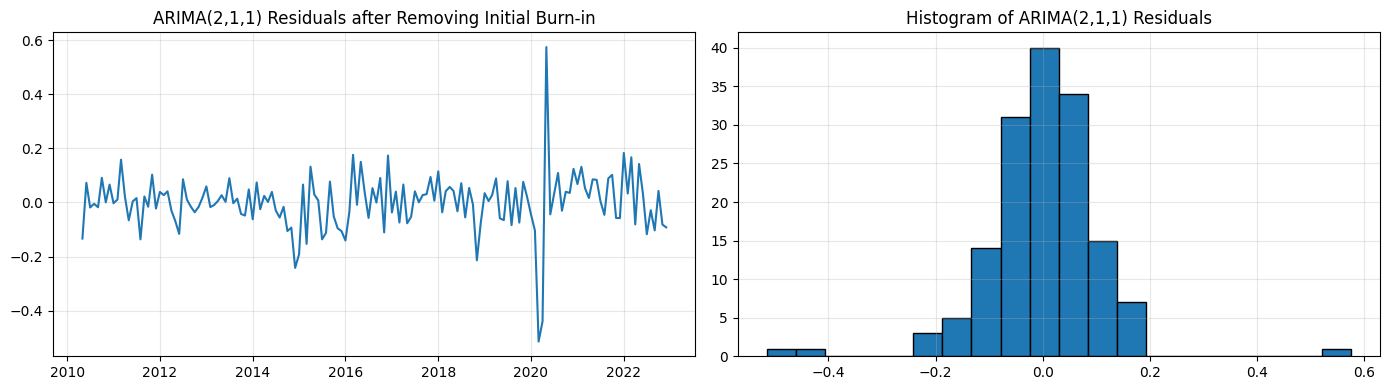

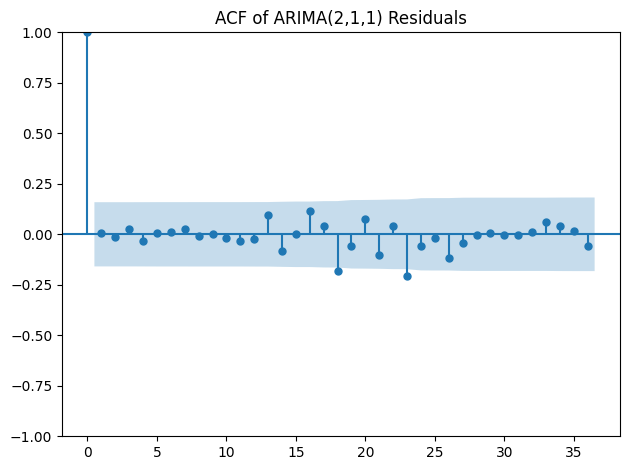

,lb_stat,lb_pvalue
6,0.356700,0.999172
12,0.777332,0.999997
18,11.723122,0.861198
24,23.942061,0.464914


In [27]:
residuals = final_arima_result.resid.copy()

burn = sum(final_order)
burn = max(burn, 1)

residuals_clean = residuals.iloc[burn:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals_clean)
axes[0].set_title("ARIMA(2,1,1) Residuals after Removing Initial Burn-in")
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_clean.dropna(), bins=20, edgecolor="black")
axes[1].set_title("Histogram of ARIMA(2,1,1) Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plot_acf(residuals_clean.dropna(), lags=36)
plt.title("ACF of ARIMA(2,1,1) Residuals")
plt.tight_layout()
plt.show()

ljung_box_final = acorr_ljungbox(
    residuals_clean.dropna(),
    lags=[6, 12, 18, 24],
    return_df=True
)

display(ljung_box_final)

### Final ARIMA Diagnostic Interpretation

ARIMA(2,1,1) is selected as the best rolling one-step ARIMA model. Its cleaned residual diagnostics show no meaningful remaining autocorrelation based on Ljung--Box p-values.

The model is therefore suitable as the final ARIMA forecasting model. However, its improvement over the random walk benchmark is modest, so the conclusion should emphasize that WTI prices are highly persistent and difficult to forecast substantially better than a naive benchmark.

## 4. ARDL Model

The ARDL model is used to examine whether the **U.S. Dollar Index** and the **Federal Funds Rate** help explain WTI price dynamics.

The main relationship is:

\[
\log(WTI_t) = f(\log(USD_t), InterestRate_t).
\]

Unlike ARIMA, ARDL includes explanatory variables and can be interpreted as an economic relationship model. It is especially useful because the variables are treated as I(1), and the ARDL framework can be used as long as no variable is I(2).

In [28]:
df_ardl = df_model[["Log_WTI", "Log_USD", "Interest_Rate"]].dropna()
print(df_ardl.head())
print(df_ardl.tail())
print(df_ardl.shape)

             Log_WTI   Log_USD  Interest_Rate
2010-01-01  4.360877  4.354662           0.11
2010-02-01  4.335817  4.383972           0.13
2010-03-01  4.396958  4.390383           0.16
2010-04-01  4.434297  4.397320           0.20
2010-05-01  4.300593  4.446895           0.20
             Log_WTI   Log_USD  Interest_Rate
2025-08-01  4.172297  4.587413           4.33
2025-09-01  4.158243  4.581755           4.22
2025-10-01  4.109144  4.592745           4.09
2025-11-01  4.095381  4.602641           3.88
2025-12-01  4.059965  4.590490           3.72
(192, 3)


In [29]:
ardl_train = df_ardl.loc[: "2022-12-01"].copy()
ardl_test = df_ardl.loc["2023-01-01":].copy()
print("ARDL train period:", ardl_train.index.min(), "to", ardl_train.index.max())
print("ARDL test period :", ardl_test.index.min(), "to", ardl_test.index.max())
print("ARDL train shape :", ardl_train.shape)
print("ARDL test shape  :", ardl_test.shape)

ARDL train period: 2010-01-01 00:00:00 to 2022-12-01 00:00:00
ARDL test period : 2023-01-01 00:00:00 to 2025-12-01 00:00:00
ARDL train shape : (156, 3)
ARDL test shape  : (36, 3)


### ARDL Sample

The ARDL model uses the same training and test split as ARIMA:

- training period: 2010–2022;
- test period: 2023–2025.

Using the same split makes the forecast evaluation more consistent across ARIMA and ARDL.

### 4.2 ARDL Lag Selection

The ARDL lag structure is selected using information criteria. AIC and BIC may select different models because AIC usually favors better in-sample fit, while BIC penalizes complexity more strongly.

Since the sample is monthly and the training period contains 156 observations, a more parsimonious model is preferred if it also passes diagnostic tests.

In [30]:
from statsmodels.tsa.ardl import ARDL
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# ================================
# Define variables
# ================================

y_train_ardl = ardl_train["Log_WTI"]
X_train_ardl = ardl_train[["Log_USD", "Interest_Rate"]]

# Maximum lag for monthly data
max_lag = 6

# Store results
ardl_search_results = []
ardl_model_store = {}

# ================================
# Manual ARDL search
# Constraint:
# p >= 1, q_usd >= 1, q_rate >= 1
# This makes the model valid for UECM / bounds test
# ================================

for p in range(1, max_lag + 1):
    for q_usd in range(1, max_lag + 1):
        for q_rate in range(1, max_lag + 1):
            try:
                model = ARDL(
                    endog=y_train_ardl,
                    lags=p,
                    exog=X_train_ardl,
                    order={
                        "Log_USD": q_usd,
                        "Interest_Rate": q_rate
                    },
                    trend="c",
                    hold_back=max_lag
                )
                
                result = model.fit()
                
                ardl_search_results.append({
                    "p_Log_WTI": p,
                    "q_Log_USD": q_usd,
                    "q_Interest_Rate": q_rate,
                    "AIC": result.aic,
                    "BIC": result.bic,
                    "HQIC": result.hqic
                })
                
                ardl_model_store[(p, q_usd, q_rate)] = model
                
            except Exception as e:
                continue

ardl_search_df = pd.DataFrame(ardl_search_results)

# Sort by AIC
ardl_search_df_aic = ardl_search_df.sort_values("AIC").reset_index(drop=True)

display(ardl_search_df_aic.head(10))

,p_Log_WTI,q_Log_USD,q_Interest_Rate,AIC,BIC,HQIC
0,2,1,4,-300.347793,-267.230804,-286.893413
1,2,1,6,-300.284543,-261.146285,-284.383913
2,2,1,5,-299.588678,-263.461055,-284.911173
3,2,1,3,-299.370837,-269.264484,-287.139582
4,4,1,4,-299.362434,-260.224176,-283.461804
5,2,2,6,-298.996234,-256.847340,-281.872478
6,3,1,4,-298.901086,-262.773462,-284.223581
7,2,2,4,-298.651486,-262.523862,-283.973981
8,3,1,6,-298.327083,-256.178189,-281.203327
9,3,1,3,-298.199445,-265.082457,-284.745065


In [31]:
# Model best with bic
ardl_search_df_bic = ardl_search_df.sort_values("BIC").reset_index(drop=True)

display(ardl_search_df_bic.head(10))

,p_Log_WTI,q_Log_USD,q_Interest_Rate,AIC,BIC,HQIC
0,2,1,3,-299.370837,-269.264484,-287.139582
1,2,1,4,-300.347793,-267.230804,-286.893413
2,3,1,3,-298.199445,-265.082457,-284.745065
3,2,2,3,-297.705433,-264.588445,-284.251054
4,2,1,5,-299.588678,-263.461055,-284.911173
5,1,1,3,-290.332577,-263.236859,-279.324448
6,3,1,4,-298.901086,-262.773462,-284.223581
7,2,2,4,-298.651486,-262.523862,-283.973981
8,2,1,6,-300.284543,-261.146285,-284.383913
9,4,1,3,-296.963131,-260.835507,-282.285626


### AIC and BIC ARDL Selection

AIC selects ARDL(2,1,4), while BIC selects ARDL(2,1,3). The two models are very similar: the AIC model only adds one additional lag of the interest rate.

Because the improvement in AIC is small and the BIC model is more parsimonious, the BIC model is a stronger candidate for the main specification.

### 4.3 Best ARDL Model According to BIC

The BIC-selected model is treated as the preferred ARDL specification because it is more parsimonious and reduces the risk of overfitting.

In [32]:
# Choose best model by BIC
best_ardl_row = ardl_search_df_bic.iloc[0]

best_ardl_order = (
    int(best_ardl_row["p_Log_WTI"]),
    int(best_ardl_row["q_Log_USD"]),
    int(best_ardl_row["q_Interest_Rate"])
)

print("Best valid ARDL order by BIC:", best_ardl_order)
print(best_ardl_row)

Best valid ARDL order by BIC: (2, 1, 3)
p_Log_WTI            2.000000
q_Log_USD            1.000000
q_Interest_Rate      3.000000
AIC               -299.370837
BIC               -269.264484
HQIC              -287.139582
Name: 0, dtype: float64


### 4.4 Best ARDL Model According to AIC

The AIC-selected model is also estimated as a robustness check. Comparing the AIC and BIC models helps determine whether adding one more lag meaningfully improves the results.

In [33]:
best_ardl_row_aic = ardl_search_df_aic.iloc[0]

best_ardl_order_aic = (
    int(best_ardl_row_aic["p_Log_WTI"]),
    int(best_ardl_row_aic["q_Log_USD"]),
    int(best_ardl_row_aic["q_Interest_Rate"])
)

print("Best valid ARDL order by AIC:", best_ardl_order_aic)
print(best_ardl_row_aic)

Best valid ARDL order by AIC: (2, 1, 4)
p_Log_WTI            2.000000
q_Log_USD            1.000000
q_Interest_Rate      4.000000
AIC               -300.347793
BIC               -267.230804
HQIC              -286.893413
Name: 0, dtype: float64


### Preferred ARDL Specification

The BIC-selected model is ARDL(2,1,3). This means:

- 2 lags of `Log_WTI`;
- 1 lag of `Log_USD`;
- 3 lags of `Interest_Rate`.

The AIC-selected model ARDL(2,1,4) is retained only as a robustness check.

### 4.5 Estimating the BIC-Selected ARDL Model

The BIC-selected model is estimated first because it is the preferred specification for interpretation. The coefficient table is used to examine short-run lag effects, while diagnostics are used to assess whether the residuals behave well.

In [34]:
# ================================
# Fit selected valid ARDL model
# ================================

ardl_model_valid = ardl_model_store[best_ardl_order]
ardl_result_valid = ardl_model_valid.fit()

print(ardl_result_valid.summary())

                              ARDL Model Results                              
Dep. Variable:                Log_WTI   No. Observations:                  156
Model:                  ARDL(2, 1, 3)   Log Likelihood                 159.685
Method:               Conditional MLE   S.D. of innovations              0.083
Date:                Mon, 01 Jun 2026   AIC                           -299.371
Time:                        00:09:39   BIC                           -269.264
Sample:                    07-01-2010   HQIC                          -287.140
                         - 12-01-2022                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.2744      0.736      3.092      0.002       0.820       3.729
Log_WTI.L1           1.1072      0.074     15.021      0.000       0.961       1.253
Log_WTI.L2          -0.2269 

### BIC ARDL Coefficient Interpretation

The BIC-selected ARDL model shows strong persistence in WTI prices through the lagged dependent variable. The interest rate terms are dynamically important, with effects distributed across current and lagged values.

The individual `Log_USD` coefficients may not all be significant in the ARDL level equation, but the long-run relationship should be interpreted through the UECM and cointegrating vector.

### 4.6 Estimating the AIC-Selected ARDL Model

The AIC-selected model is estimated for comparison. If the AIC model does not improve diagnostics or forecast performance, the more parsimonious BIC model remains preferable.

In [35]:
ardl_model_aic = ardl_model_store[best_ardl_order_aic]
ardl_result_aic = ardl_model_aic.fit()

print(ardl_result_aic.summary())


                              ARDL Model Results                              
Dep. Variable:                Log_WTI   No. Observations:                  156
Model:                  ARDL(2, 1, 4)   Log Likelihood                 161.174
Method:               Conditional MLE   S.D. of innovations              0.083
Date:                Mon, 01 Jun 2026   AIC                           -300.348
Time:                        00:09:39   BIC                           -267.231
Sample:                    07-01-2010   HQIC                          -286.893
                         - 12-01-2022                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.2850      0.731      3.126      0.002       0.840       3.730
Log_WTI.L1           1.1657      0.081     14.366      0.000       1.005       1.326
Log_WTI.L2          -0.2899 

### AIC ARDL Interpretation

The AIC-selected model adds one more interest rate lag. Since the model is more complex, it must improve diagnostics or forecast performance to justify replacing the BIC model.

The later forecast comparison shows that this additional lag does not improve performance, which supports keeping the BIC-selected ARDL(2,1,3) as the preferred model.

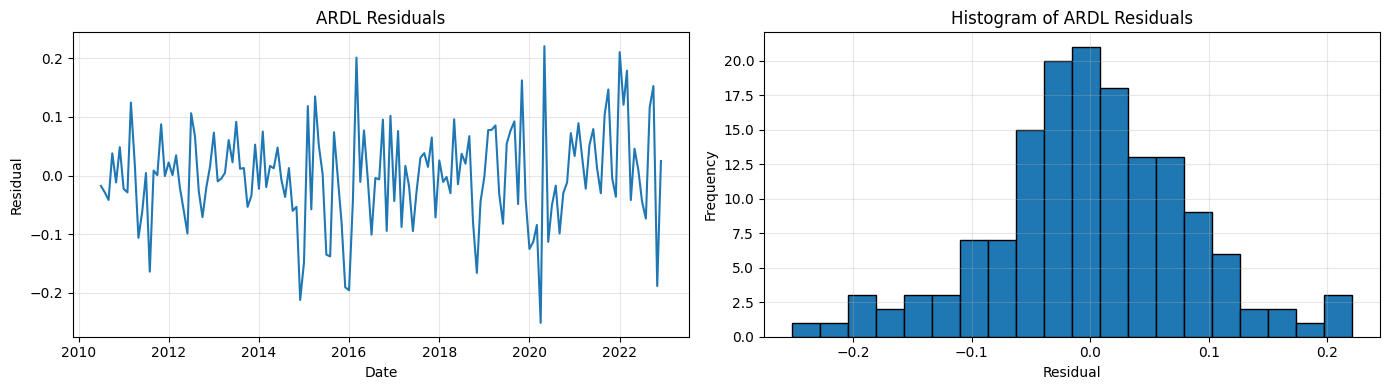

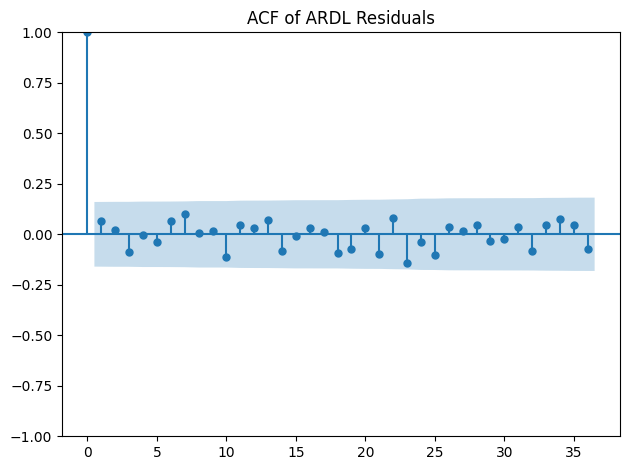

Ljung-Box Test for ARDL Residuals


,lb_stat,lb_pvalue
6,2.832045,0.829612
12,7.112686,0.850078
18,10.798012,0.902731
24,18.520152,0.777072


Jarque-Bera Test for ARDL Residuals
JB Statistic: 2.0265
p-value     : 0.3630
ARCH Test for Heteroskedasticity
ARCH Statistic: 14.0161
p-value       : 0.2997


In [36]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf

# ================================
# Residual diagnostics
# ================================

ardl_resid = ardl_result_valid.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ardl_resid)
axes[0].set_title("ARDL Residuals")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")
axes[0].grid(True, alpha=0.3)

axes[1].hist(ardl_resid, bins=20, edgecolor="black")
axes[1].set_title("Histogram of ARDL Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ACF of residuals
plot_acf(ardl_resid, lags=36)
plt.title("ACF of ARDL Residuals")
plt.tight_layout()
plt.show()

# Ljung-Box test
ljung_ardl = acorr_ljungbox(
    ardl_resid,
    lags=[6, 12, 18, 24],
    return_df=True
)

print("Ljung-Box Test for ARDL Residuals")
display(ljung_ardl)

# Jarque-Bera test
jb_stat, jb_pvalue = jarque_bera(ardl_resid)

print("Jarque-Bera Test for ARDL Residuals")
print(f"JB Statistic: {jb_stat:.4f}")
print(f"p-value     : {jb_pvalue:.4f}")

# ARCH test for heteroskedasticity
arch_stat, arch_pvalue, _, _ = het_arch(ardl_resid, nlags=12)

print("ARCH Test for Heteroskedasticity")
print(f"ARCH Statistic: {arch_stat:.4f}")
print(f"p-value       : {arch_pvalue:.4f}")

### BIC ARDL Residual Diagnostics

The BIC-selected ARDL model performs well in residual diagnostics:

- Ljung--Box p-values at lags 6, 12, 18, and 24 are all above 0.05, so there is no evidence of residual autocorrelation.
- Jarque--Bera p-value is 0.3630, so residual normality is not rejected.
- ARCH test p-value is 0.2997, so there is no strong evidence of remaining conditional heteroskedasticity.

These results support using the BIC-selected ARDL model for economic interpretation.

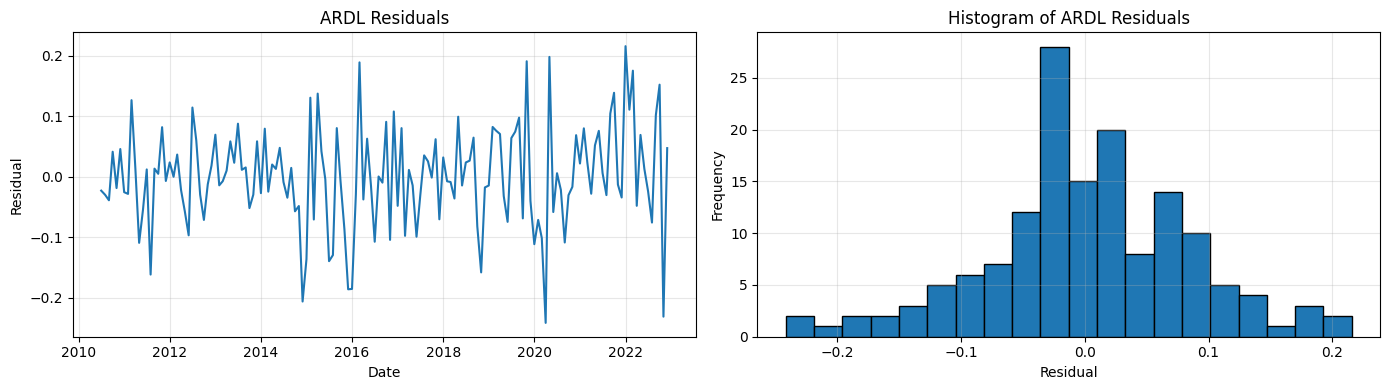

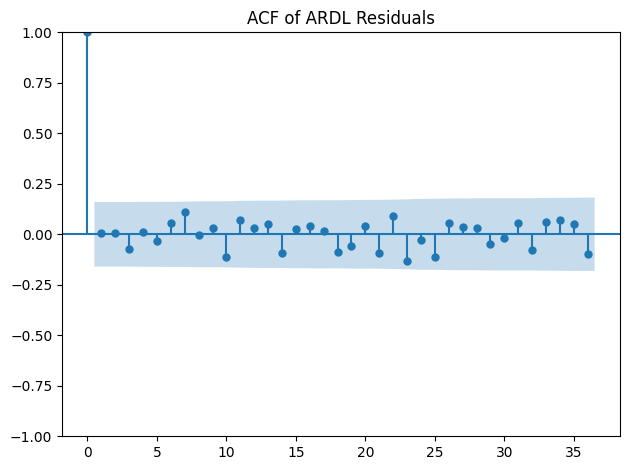

Ljung-Box Test for ARDL Residuals


,lb_stat,lb_pvalue
6,1.591159,0.953211
12,6.710206,0.876155
18,10.253009,0.923334
24,17.435662,0.829496


Jarque-Bera Test for ARDL Residuals
JB Statistic: 2.3694
p-value     : 0.3058
ARCH Test for Heteroskedasticity
ARCH Statistic: 11.2464
p-value       : 0.5079


In [37]:
# ================================
# Residual diagnostics
# ================================

ardl_resid_aic = ardl_result_aic.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ardl_resid_aic)
axes[0].set_title("ARDL Residuals")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")
axes[0].grid(True, alpha=0.3)

axes[1].hist(ardl_resid_aic, bins=20, edgecolor="black")
axes[1].set_title("Histogram of ARDL Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ACF of residuals
plot_acf(ardl_resid_aic, lags=36)
plt.title("ACF of ARDL Residuals")
plt.tight_layout()
plt.show()

# Ljung-Box test
ljung_ardl = acorr_ljungbox(
    ardl_resid_aic,
    lags=[6, 12, 18, 24],
    return_df=True
)

print("Ljung-Box Test for ARDL Residuals")
display(ljung_ardl)

# Jarque-Bera test
jb_stat, jb_pvalue = jarque_bera(ardl_resid_aic)

print("Jarque-Bera Test for ARDL Residuals")
print(f"JB Statistic: {jb_stat:.4f}")
print(f"p-value     : {jb_pvalue:.4f}")

# ARCH test for heteroskedasticity
arch_stat, arch_pvalue, _, _ = het_arch(ardl_resid_aic, nlags=12)

print("ARCH Test for Heteroskedasticity")
print(f"ARCH Statistic: {arch_stat:.4f}")
print(f"p-value       : {arch_pvalue:.4f}")

### AIC ARDL Residual Diagnostics

The AIC-selected ARDL model also passes the main residual diagnostic tests. However, passing diagnostics alone is not enough to choose the AIC model, because it is less parsimonious and does not improve forecast performance.

Therefore, the BIC model remains preferable.

In [38]:
print("AR lags on BIC:", ardl_model_valid.ar_lags)
print("DL lags on BIC:", ardl_model_valid.dl_lags)
print("AR lags on AIC:", ardl_model_aic.ar_lags)
print("DL lags on AIC:", ardl_model_aic.dl_lags)


AR lags on BIC: [1, 2]
DL lags on BIC: {'Log_USD': [0, 1], 'Interest_Rate': [0, 1, 2, 3]}
AR lags on AIC: [1, 2]
DL lags on AIC: {'Log_USD': [0, 1], 'Interest_Rate': [0, 1, 2, 3, 4]}


### Lag Structure Check

The lag structure confirms that both ARDL models include at least one lag of each explanatory variable. This matters because converting ARDL to UECM for bounds testing requires included exogenous variables to have lag length of at least one.

In [39]:
from statsmodels.tsa.ardl import UECM

# ================================
# Convert valid ARDL to UECM
# ================================

uecm_model = UECM.from_ardl(ardl_model_valid)
uecm_result = uecm_model.fit()

print(uecm_result.summary())

                              UECM Model Results                              
Dep. Variable:              D.Log_WTI   No. Observations:                  156
Model:                  UECM(2, 1, 3)   Log Likelihood                 159.685
Method:               Conditional MLE   S.D. of innovations              4.219
Date:                Mon, 01 Jun 2026   AIC                           -299.371
Time:                        00:09:40   BIC                           -269.264
Sample:                    07-01-2010   HQIC                          -287.140
                         - 12-01-2022                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.2744      0.736      3.092      0.002       0.820       3.729
Log_WTI.L1            -0.1197      0.035     -3.424      0.001      -0.189      -0.051
Log_USD.L1          

### UECM Representation

The BIC-selected ARDL model is converted into an unrestricted error correction model (UECM). This representation is used to test whether a long-run relationship exists among `Log_WTI`, `Log_USD`, and `Interest_Rate`.

In this form, the coefficient on `Log_WTI.L1` is interpreted as the error correction speed.

In [40]:
# ================================
# Bounds test
# Case 3: unrestricted constant, no deterministic trend
# ================================

bounds_result = uecm_result.bounds_test(case=3)

print(bounds_result)

BoundsTestResult
Stat: 3.90235
Upper P-value: 0.0834
Lower P-value: 0.0185
Null: No Cointegration
Alternative: Possible Cointegration



### Bounds Test Interpretation

The bounds test statistic is 3.9024. The lower-bound p-value is 0.0185, while the upper-bound p-value is 0.0834.

This provides **weak evidence of cointegration at the 10% level**, but the evidence is not strong enough at the 5% level. Therefore, the long-run coefficients should be interpreted cautiously.

In [41]:
# ================================
# Cointegrating relationship summary
# ================================

try:
    print(uecm_result.ci_summary())
except Exception as e:
    print("ci_summary() is not available in this statsmodels version.")
    print(e)

                                Cointegrating Vector                                
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -19.0039      3.319     -5.725      0.000     -25.566     -12.442
Log_WTI.L1           1.0000          0        nan        nan       1.000       1.000
Log_USD.L1           3.3018      0.744      4.439      0.000       1.831       4.772
Interest_Rate.L1    -0.0493      0.092     -0.533      0.594      -0.232       0.133


### Cointegrating Vector

The cointegrating vector summarizes the implied long-run relationship among the variables. It is useful for understanding the direction of long-run association, but because the bounds test evidence is only weak at the 10% level, the results should not be overstated.

In [42]:
# ================================
# Extract error correction speed
# ================================

print(uecm_result.params)

for name, value in uecm_result.params.items():
    if "Log_WTI.L1" in name:
        print("Potential error correction speed term:")
        print(name, value)

const                 2.274366
Log_WTI.L1           -0.119679
Log_USD.L1           -0.395158
Interest_Rate.L1      0.005897
D.Log_WTI.L1          0.226864
D.Log_USD.L0         -0.713609
D.Interest_Rate.L0    0.464768
D.Interest_Rate.L1   -0.048261
D.Interest_Rate.L2   -0.325946
dtype: float64
Potential error correction speed term:
Log_WTI.L1 -0.11967913452027262
Potential error correction speed term:
D.Log_WTI.L1 0.22686439703529337


In [43]:
# ================================
# Correct long-run coefficients from UECM
# ================================

params = uecm_result.params

lambda_y = params["Log_WTI.L1"]  # error correction speed coefficient

long_run_const = -params["const"] / lambda_y
long_run_usd = -params["Log_USD.L1"] / lambda_y
long_run_rate = -params["Interest_Rate.L1"] / lambda_y

long_run_df = pd.DataFrame({
    "Variable": ["Constant", "Log_USD", "Interest_Rate"],
    "Long_Run_Coefficient": [long_run_const, long_run_usd, long_run_rate]
})

display(long_run_df)

print("Speed of adjustment:", lambda_y)
print("Monthly adjustment speed (%):", abs(lambda_y) * 100)

,Variable,Long_Run_Coefficient
0,Constant,19.003865
1,Log_USD,-3.301814
2,Interest_Rate,0.049270


Speed of adjustment: -0.11967913452027262
Monthly adjustment speed (%): 11.967913452027263


### Error Correction and Long-Run Coefficients

The error correction coefficient is:

\[
Log\_WTI.L1 = -0.1197.
\]

This means that approximately 12% of deviations from the long-run equilibrium are corrected each month.

The long-run coefficient of `Log_USD` is about -3.30, suggesting a negative long-run association between dollar strength and WTI prices. The long-run coefficient of `Interest_Rate` is small and positive, but it should be interpreted cautiously because the long-run evidence is weak.

### 4.10 Fixed Dynamic Conditional Forecast with the BIC-Selected ARDL Model

This forecast uses the BIC-selected ARDL model to predict the entire 2023–2025 test period dynamically.

This is a difficult forecasting exercise because forecast errors can accumulate over time. It should not be directly compared with rolling one-step forecasts.

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ================================
# Conditional ARDL forecast
# ================================

X_test_ardl = ardl_test[["Log_USD", "Interest_Rate"]]

try:
    ardl_forecast_log = ardl_result_valid.forecast(
        steps=len(ardl_test),
        exog=X_test_ardl
    )
except Exception as e:
    print("forecast() failed. Trying predict() instead.")
    print(e)
    
    ardl_forecast_log = ardl_result_valid.predict(
        start=ardl_test.index[0],
        end=ardl_test.index[-1],
        exog_oos=X_test_ardl
    )

# Align index
ardl_forecast_log.index = ardl_test.index

# Convert log forecast to price
ardl_forecast_price = np.exp(ardl_forecast_log)

ardl_forecast_df = pd.DataFrame({
    "Actual_WTI": np.exp(ardl_test["Log_WTI"]),
    "ARDL_Forecast_WTI": ardl_forecast_price
})

display(ardl_forecast_df.head())
display(ardl_forecast_df.tail())

# Forecast metrics
mae_ardl = mean_absolute_error(
    ardl_forecast_df["Actual_WTI"],
    ardl_forecast_df["ARDL_Forecast_WTI"]
)

rmse_ardl = np.sqrt(mean_squared_error(
    ardl_forecast_df["Actual_WTI"],
    ardl_forecast_df["ARDL_Forecast_WTI"]
))

mape_ardl = np.mean(
    np.abs(
        (ardl_forecast_df["Actual_WTI"] - ardl_forecast_df["ARDL_Forecast_WTI"])
        / ardl_forecast_df["Actual_WTI"]
    )
) * 100

print("Conditional ARDL Forecast Evaluation")
print(f"MAE  : {mae_ardl:.4f}")
print(f"RMSE : {rmse_ardl:.4f}")
print(f"MAPE : {mape_ardl:.2f}%")

,Actual_WTI,ARDL_Forecast_WTI
2023-01-01,78.123000,62.307023
2023-02-01,76.832632,57.415826
2023-03-01,73.277826,52.681508
2023-04-01,79.446316,52.100961
2023-05-01,71.578182,55.662861


,Actual_WTI,ARDL_Forecast_WTI
2025-08-01,64.864286,54.672906
2025-09-01,63.959048,52.755091
2025-10-01,60.894545,49.835628
2025-11-01,60.062222,46.951194
2025-12-01,57.972273,46.535419


Conditional ARDL Forecast Evaluation
MAE  : 23.5587
RMSE : 25.0143
MAPE : 31.50%


### BIC ARDL Fixed Forecast Interpretation

The fixed dynamic ARDL forecast performs poorly:

- MAE = 23.56
- RMSE = 25.01
- MAPE = 31.50%

This does not mean the ARDL model is useless. Rather, it shows that this ARDL specification is better suited for economic interpretation than for long-horizon dynamic forecasting. Dynamic ARDL forecasts can accumulate errors over time.

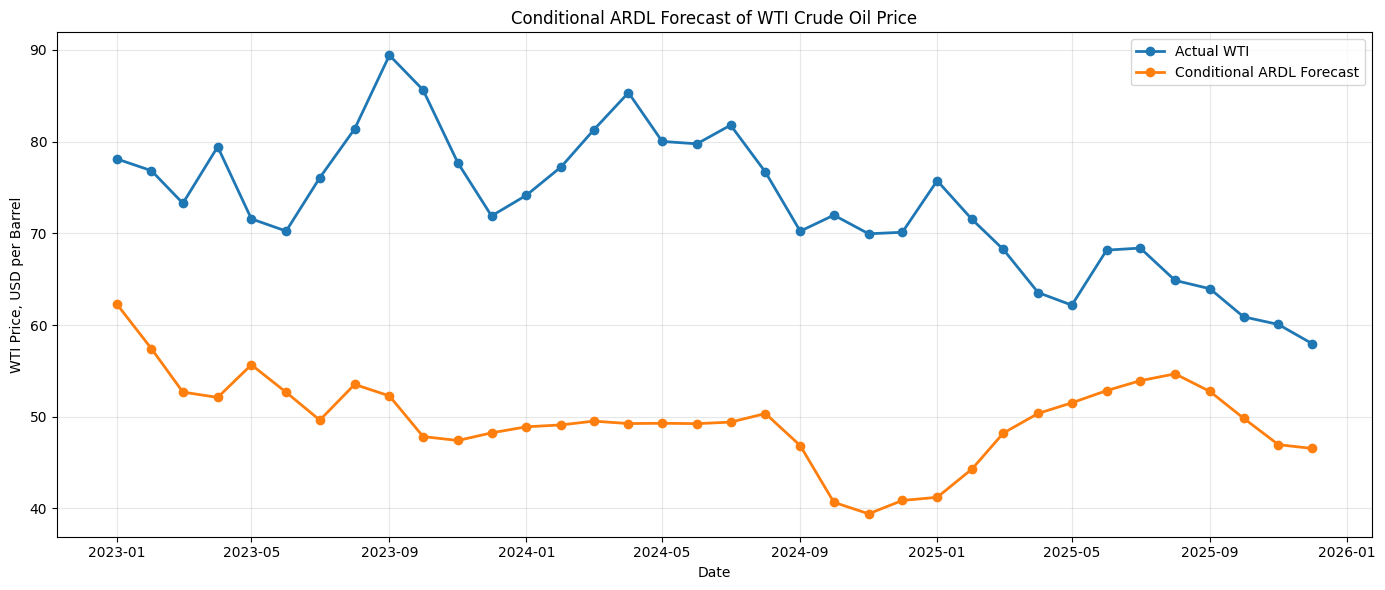

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(
    ardl_test.index,
    ardl_forecast_df["Actual_WTI"],
    label="Actual WTI",
    linewidth=2,
    marker="o"
)

plt.plot(
    ardl_test.index,
    ardl_forecast_df["ARDL_Forecast_WTI"],
    label="Conditional ARDL Forecast",
    linewidth=2,
    marker="o"
)

plt.title("Conditional ARDL Forecast of WTI Crude Oil Price")
plt.xlabel("Date")
plt.ylabel("WTI Price, USD per Barrel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### BIC ARDL Fixed Forecast Plot

The plot shows that the fixed ARDL forecast substantially underpredicts actual WTI prices during much of the test period.

This supports the conclusion that the fixed dynamic ARDL forecast should not be treated as the main forecasting result.

### 4.11 Rolling One-Step Conditional Forecast with the BIC-Selected ARDL Model

The rolling ARDL forecast updates the information set each month and then produces a one-month-ahead forecast.

This procedure is more realistic for short-run monthly forecasting. It is still called **conditional** because the actual out-of-sample values of the U.S. Dollar Index and the Federal Funds Rate are used as explanatory variables.

In [46]:
from statsmodels.tsa.ardl import ARDL
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Selected BIC ARDL order
p_wti = 2
q_usd = 1
q_rate = 3

rolling_ardl_forecasts_log = []

for i in range(len(ardl_test)):
    
    # Data available up to previous month
    current_end = ardl_test.index[i] - pd.offsets.MonthBegin(1)
    rolling_train = df_ardl.loc[:current_end].copy()
    
    y_roll = rolling_train["Log_WTI"]
    X_roll = rolling_train[["Log_USD", "Interest_Rate"]]
    
    # Fit ARDL on rolling/expanding window
    model_roll = ARDL(
        endog=y_roll,
        lags=p_wti,
        exog=X_roll,
        order={
            "Log_USD": q_usd,
            "Interest_Rate": q_rate
        },
        trend="c",
        hold_back=max(p_wti, q_usd, q_rate)
    )
    
    result_roll = model_roll.fit()
    
    # Exogenous values for the forecast month
    X_oos = ardl_test[["Log_USD", "Interest_Rate"]].iloc[[i]]
    
    # One-step conditional forecast
    forecast_log = result_roll.forecast(
        steps=1,
        exog=X_oos
    )
    
    rolling_ardl_forecasts_log.append(float(forecast_log.iloc[0]))

# Convert forecasts to price
rolling_ardl_forecast_log = pd.Series(
    rolling_ardl_forecasts_log,
    index=ardl_test.index
)

rolling_ardl_forecast_price = np.exp(rolling_ardl_forecast_log)

rolling_ardl_df = pd.DataFrame({
    "Actual_WTI": np.exp(ardl_test["Log_WTI"]),
    "Rolling_ARDL_Forecast_WTI": rolling_ardl_forecast_price
})

display(rolling_ardl_df.head())
display(rolling_ardl_df.tail())

# Metrics
mae_roll_ardl = mean_absolute_error(
    rolling_ardl_df["Actual_WTI"],
    rolling_ardl_df["Rolling_ARDL_Forecast_WTI"]
)

rmse_roll_ardl = np.sqrt(mean_squared_error(
    rolling_ardl_df["Actual_WTI"],
    rolling_ardl_df["Rolling_ARDL_Forecast_WTI"]
))

mape_roll_ardl = np.mean(
    np.abs(
        (rolling_ardl_df["Actual_WTI"] - rolling_ardl_df["Rolling_ARDL_Forecast_WTI"])
        / rolling_ardl_df["Actual_WTI"]
    )
) * 100

print("Rolling One-Step Conditional ARDL Forecast Evaluation")
print(f"MAE  : {mae_roll_ardl:.4f}")
print(f"RMSE : {rmse_roll_ardl:.4f}")
print(f"MAPE : {mape_roll_ardl:.2f}%")

,Actual_WTI,Rolling_ARDL_Forecast_WTI
2023-01-01,78.123000,62.428392
2023-02-01,76.832632,75.659493
2023-03-01,73.277826,70.902632
2023-04-01,79.446316,73.032583
2023-05-01,71.578182,85.293422


,Actual_WTI,Rolling_ARDL_Forecast_WTI
2025-08-01,64.864286,70.038747
2025-09-01,63.959048,63.068581
2025-10-01,60.894545,62.223141
2025-11-01,60.062222,58.438380
2025-12-01,57.972273,60.437291


Rolling One-Step Conditional ARDL Forecast Evaluation
MAE  : 4.7709
RMSE : 6.0814
MAPE : 6.43%


### BIC ARDL Rolling Forecast Interpretation

The rolling one-step conditional ARDL forecast performs much better:

- MAE = 4.77
- RMSE = 6.08
- MAPE = 6.43%

This result is reasonable but still weaker than the best rolling ARIMA model. The ARDL model remains useful because it provides economic interpretation of the role of USD and interest rates.

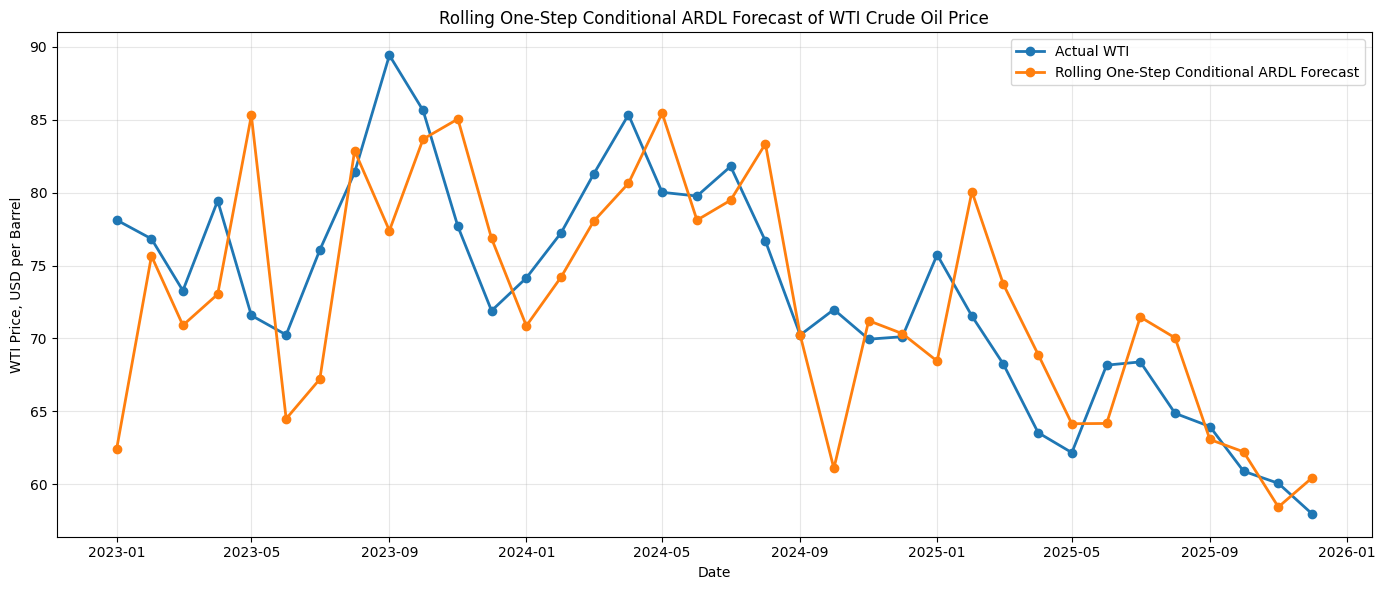

In [47]:
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_ardl_df.index,
    rolling_ardl_df["Actual_WTI"],
    label="Actual WTI",
    linewidth=2,
    marker="o"
)

plt.plot(
    rolling_ardl_df.index,
    rolling_ardl_df["Rolling_ARDL_Forecast_WTI"],
    label="Rolling One-Step Conditional ARDL Forecast",
    linewidth=2,
    marker="o"
)

plt.title("Rolling One-Step Conditional ARDL Forecast of WTI Crude Oil Price")
plt.xlabel("Date")
plt.ylabel("WTI Price, USD per Barrel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### BIC ARDL Rolling Forecast Plot

The rolling ARDL forecast follows actual WTI prices much more closely than the fixed ARDL forecast. This confirms that updating the model as new monthly data become available substantially improves short-run forecast performance.

### 4.12 Fixed Dynamic Conditional Forecast with the AIC-Selected ARDL Model

The AIC-selected model is evaluated to check whether the additional interest rate lag improves forecast accuracy. If the AIC model performs worse, this supports the choice of the BIC model.

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ================================
# Conditional ARDL forecast
# ================================

X_test_ardl = ardl_test[["Log_USD", "Interest_Rate"]]

try:
    ardl_forecast_log = ardl_result_aic.forecast(
        steps=len(ardl_test),
        exog=X_test_ardl
    )
except Exception as e:
    print("forecast() failed. Trying predict() instead.")
    print(e)
    
    ardl_forecast_log = ardl_result_aic.predict(
        start=ardl_test.index[0],
        end=ardl_test.index[-1],
        exog_oos=X_test_ardl
    )

# Align index
ardl_forecast_log.index = ardl_test.index

# Convert log forecast to price
ardl_forecast_price = np.exp(ardl_forecast_log)

ardl_forecast_df = pd.DataFrame({
    "Actual_WTI": np.exp(ardl_test["Log_WTI"]),
    "ARDL_Forecast_WTI": ardl_forecast_price
})

display(ardl_forecast_df.head())
display(ardl_forecast_df.tail())

# Forecast metrics
mae_ardl = mean_absolute_error(
    ardl_forecast_df["Actual_WTI"],
    ardl_forecast_df["ARDL_Forecast_WTI"]
)

rmse_ardl = np.sqrt(mean_squared_error(
    ardl_forecast_df["Actual_WTI"],
    ardl_forecast_df["ARDL_Forecast_WTI"]
))

mape_ardl = np.mean(
    np.abs(
        (ardl_forecast_df["Actual_WTI"] - ardl_forecast_df["ARDL_Forecast_WTI"])
        / ardl_forecast_df["Actual_WTI"]
    )
) * 100

print("Conditional ARDL Forecast Evaluation")
print(f"MAE  : {mae_ardl:.4f}")
print(f"RMSE : {rmse_ardl:.4f}")
print(f"MAPE : {mape_ardl:.2f}%")

,Actual_WTI,ARDL_Forecast_WTI
2023-01-01,78.123000,62.765974
2023-02-01,76.832632,60.485619
2023-03-01,73.277826,56.415151
2023-04-01,79.446316,55.278803
2023-05-01,71.578182,58.866664


,Actual_WTI,ARDL_Forecast_WTI
2025-08-01,64.864286,48.632406
2025-09-01,63.959048,47.368013
2025-10-01,60.894545,45.093194
2025-11-01,60.062222,43.049733
2025-12-01,57.972273,42.608372


Conditional ARDL Forecast Evaluation
MAE  : 26.1328
RMSE : 27.4090
MAPE : 35.28%


### AIC ARDL Fixed Forecast Interpretation

The AIC-selected ARDL(2,1,4) model performs worse than the BIC model in fixed dynamic forecasting:

- MAE = 26.13
- RMSE = 27.41
- MAPE = 35.28%

This supports the decision not to use the AIC model as the preferred specification.

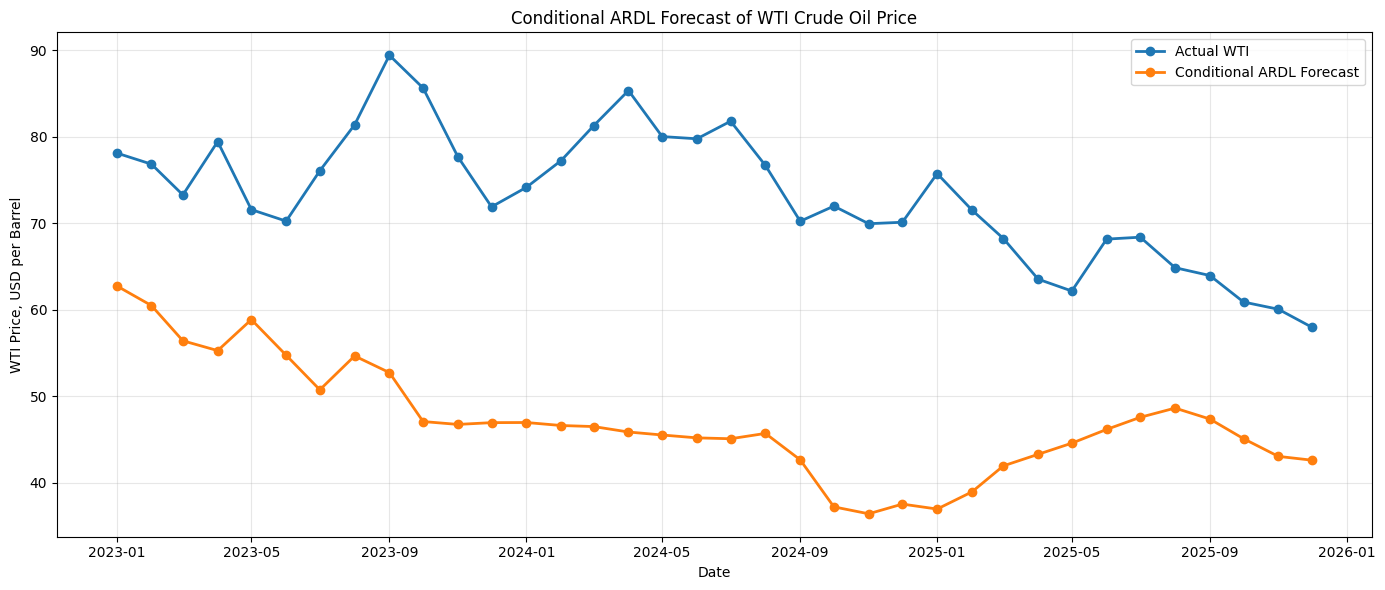

In [49]:
plt.figure(figsize=(14, 6))

plt.plot(
    ardl_test.index,
    ardl_forecast_df["Actual_WTI"],
    label="Actual WTI",
    linewidth=2,
    marker="o"
)

plt.plot(
    ardl_test.index,
    ardl_forecast_df["ARDL_Forecast_WTI"],
    label="Conditional ARDL Forecast",
    linewidth=2,
    marker="o"
)

plt.title("Conditional ARDL Forecast of WTI Crude Oil Price")
plt.xlabel("Date")
plt.ylabel("WTI Price, USD per Barrel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### AIC ARDL Fixed Forecast Plot

The AIC model also underpredicts WTI prices in the dynamic test forecast. Adding one more interest rate lag does not solve the long-horizon forecasting problem.

### 4.13 Rolling One-Step Conditional Forecast with the AIC-Selected ARDL Model

This rolling forecast is used as a robustness check against the BIC-selected ARDL model.

In [50]:
from statsmodels.tsa.ardl import ARDL
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Selected AIC ARDL order
p_wti = 2
q_usd = 1
q_rate = 4

rolling_ardl_forecasts_log = []

for i in range(len(ardl_test)):
    
    # Data available up to previous month
    current_end = ardl_test.index[i] - pd.offsets.MonthBegin(1)
    rolling_train = df_ardl.loc[:current_end].copy()
    
    y_roll = rolling_train["Log_WTI"]
    X_roll = rolling_train[["Log_USD", "Interest_Rate"]]
    
    # Fit ARDL on rolling/expanding window
    model_roll = ARDL(
        endog=y_roll,
        lags=p_wti,
        exog=X_roll,
        order={
            "Log_USD": q_usd,
            "Interest_Rate": q_rate
        },
        trend="c",
        hold_back=max(p_wti, q_usd, q_rate)
    )
    
    result_roll = model_roll.fit()
    
    # Exogenous values for the forecast month
    X_oos = ardl_test[["Log_USD", "Interest_Rate"]].iloc[[i]]
    
    # One-step conditional forecast
    forecast_log = result_roll.forecast(
        steps=1,
        exog=X_oos
    )
    
    rolling_ardl_forecasts_log.append(float(forecast_log.iloc[0]))

# Convert forecasts to price
rolling_ardl_forecast_log = pd.Series(
    rolling_ardl_forecasts_log,
    index=ardl_test.index
)

rolling_ardl_forecast_price = np.exp(rolling_ardl_forecast_log)

rolling_ardl_df = pd.DataFrame({
    "Actual_WTI": np.exp(ardl_test["Log_WTI"]),
    "Rolling_ARDL_Forecast_WTI": rolling_ardl_forecast_price
})

display(rolling_ardl_df.head())
display(rolling_ardl_df.tail())

# Metrics
mae_roll_ardl = mean_absolute_error(
    rolling_ardl_df["Actual_WTI"],
    rolling_ardl_df["Rolling_ARDL_Forecast_WTI"]
)

rmse_roll_ardl = np.sqrt(mean_squared_error(
    rolling_ardl_df["Actual_WTI"],
    rolling_ardl_df["Rolling_ARDL_Forecast_WTI"]
))

mape_roll_ardl = np.mean(
    np.abs(
        (rolling_ardl_df["Actual_WTI"] - rolling_ardl_df["Rolling_ARDL_Forecast_WTI"])
        / rolling_ardl_df["Actual_WTI"]
    )
) * 100

print("Rolling One-Step Conditional ARDL Forecast Evaluation")
print(f"MAE  : {mae_roll_ardl:.4f}")
print(f"RMSE : {rmse_roll_ardl:.4f}")
print(f"MAPE : {mape_roll_ardl:.2f}%")

,Actual_WTI,Rolling_ARDL_Forecast_WTI
2023-01-01,78.123000,62.872506
2023-02-01,76.832632,80.067411
2023-03-01,73.277826,71.220994
2023-04-01,79.446316,72.106011
2023-05-01,71.578182,85.458285


,Actual_WTI,Rolling_ARDL_Forecast_WTI
2025-08-01,64.864286,69.839615
2025-09-01,63.959048,62.932778
2025-10-01,60.894545,62.195048
2025-11-01,60.062222,58.696665
2025-12-01,57.972273,60.319285


Rolling One-Step Conditional ARDL Forecast Evaluation
MAE  : 4.9902
RMSE : 6.2455
MAPE : 6.69%


### AIC ARDL Rolling Forecast Interpretation

The AIC-selected ARDL model also performs reasonably in rolling forecasts, but it is slightly worse than the BIC-selected model:

- AIC ARDL MAPE = 6.69%
- BIC ARDL MAPE = 6.43%

Therefore, the BIC model is preferred because it is more parsimonious and performs slightly better.

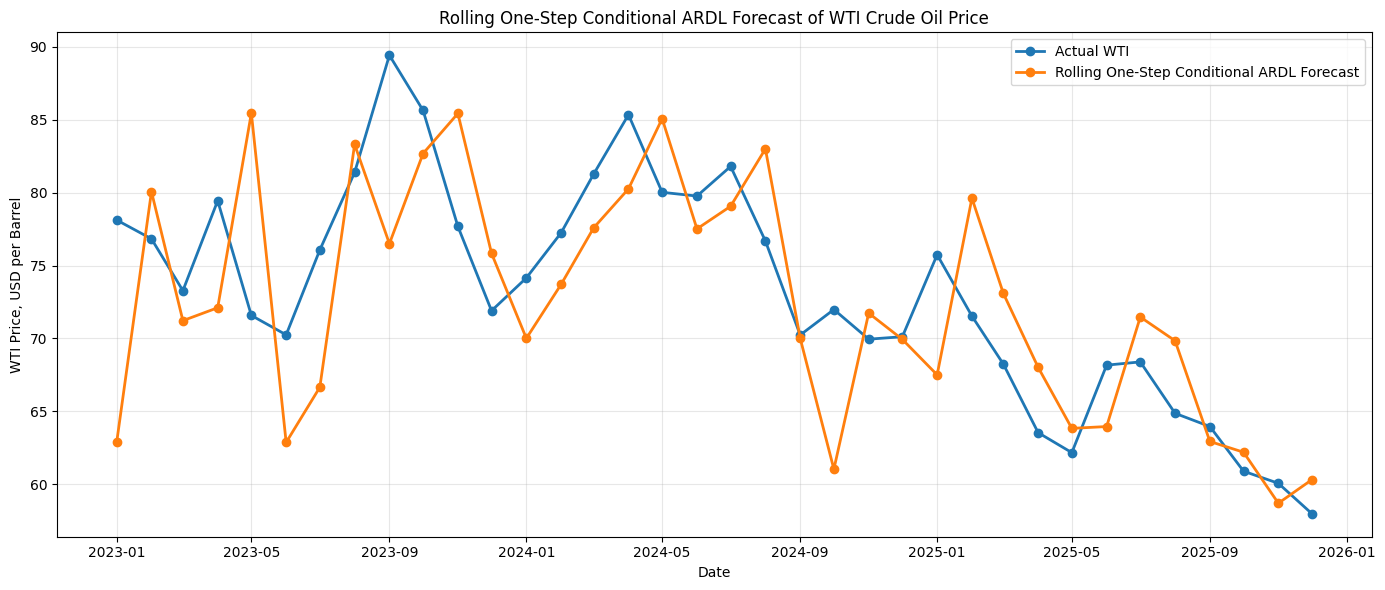

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_ardl_df.index,
    rolling_ardl_df["Actual_WTI"],
    label="Actual WTI",
    linewidth=2,
    marker="o"
)

plt.plot(
    rolling_ardl_df.index,
    rolling_ardl_df["Rolling_ARDL_Forecast_WTI"],
    label="Rolling One-Step Conditional ARDL Forecast",
    linewidth=2,
    marker="o"
)

plt.title("Rolling One-Step Conditional ARDL Forecast of WTI Crude Oil Price")
plt.xlabel("Date")
plt.ylabel("WTI Price, USD per Barrel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Final Modeling Summary

The results lead to three main conclusions.

First, **ARIMA is better for short-run forecasting**. The best rolling ARIMA model is ARIMA(2,1,1), with a MAPE of about 4.82%. However, it only slightly improves on the random walk benchmark, which confirms that monthly WTI prices are highly persistent.

Second, **ARDL is better for economic interpretation**. The BIC-selected ARDL(2,1,3) passes residual diagnostic tests and provides evidence of dynamic effects from the U.S. Dollar Index and the Federal Funds Rate.

Third, the bounds test provides only weak evidence of cointegration at the 10% level. Therefore, the long-run relationship should be interpreted cautiously.

The overall interpretation is:

> ARIMA is the stronger short-run forecasting model, while ARDL is the more useful model for explaining the macro-financial relationship between WTI prices, the U.S. Dollar Index, and the Federal Funds Rate.